In [1]:
import numpy as np
import polars as pl
import ssm
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [25]:
def firing_by_angle_bin(angles, neural_activity, nbins):
    angles_firing = np.zeros(nbins - 1)
    angles_std = np.zeros(nbins - 1)
    unique_groups, group_counts = np.unique(angles, return_counts=True)
    # mean firing
    group_sums = np.bincount(angles, weights=neural_activity)
    angles_firing[unique_groups] = group_sums[unique_groups] / group_counts
    # std of firing
    group_sums_squared = np.bincount(angles, weights=neural_activity**2)
    mean_squared = angles_firing[unique_groups] ** 2
    variance = (group_sums_squared[unique_groups] / group_counts) - mean_squared
    angles_std[unique_groups] = np.sqrt(variance)
    return angles_firing, angles_std

Text(0.5, 1.0, 'firing by category in the two states')

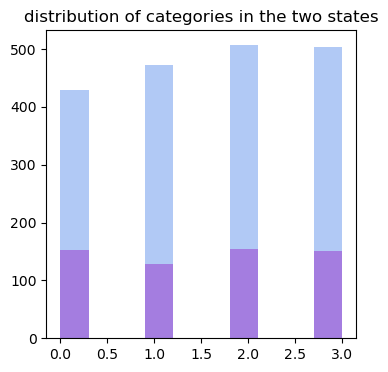

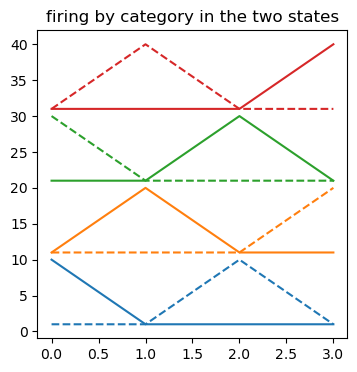

In [49]:
'''Generate synthetic data'''
time = 2500
# states
states = [0,1] # what are our states
start_prob = [.9,.1] # probability we start with one state
transition_matrix = [[.8,.2],[.65,.35]] # transition probability between states
all_state = np.zeros((time,),dtype = int)
all_state[0] = np.random.choice(states,p=start_prob)
for t in range(1,time):
    trans = transition_matrix[all_state[t-1]]
    all_state[t] = np.random.choice(states,p=trans)

# data
obs_cat = 4
obs = np.zeros_like(all_state)
for i in states:
    t_in_state = np.sum(all_state == i)
    # uniformly assign time in each state to each category of obs
    obs[all_state == i] = np.random.randint(obs_cat,size = t_in_state) 

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.hist(obs[all_state == 0], alpha = .5, color = ['cornflowerblue'])
axs.hist(obs[all_state == 1], alpha = .5, color = ['darkorchid'])
axs.set_title("distribution of categories in the two states")

# inputs
n_inpt = 4
W = [[10,1,1,1],[1,10,1,1],[1,1,10,1],[1,1,1,10]]
# W = [[10,2,1,1],[1,8,2,1],[.5,1,4,0],[0,1,1,15]]
inputs = np.zeros((time,n_inpt))
idx = np.arange(n_inpt)
for i in states:
    for j in np.arange(n_inpt):
        o = obs[all_state == i]
        w = np.array(W[idx[j]])
        inputs[all_state == i,j] = w[o]
    idx = np.roll(idx,2)

fig,ax = plt.subplots(1,1,figsize = (4,4))
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
linetype = ['-','--']
shift = 0
for idx in np.arange(n_inpt):
    for i in np.unique(all_state):
        i = int(i)
        y, error = firing_by_angle_bin(obs[all_state == i],inputs[all_state == i,idx], obs_cat+1)
        ax.fill_between(np.arange(obs_cat), y-error+shift, y+error+shift, alpha=.5, facecolor = colorz[idx], linewidth=0)
        ax.plot(np.arange(obs_cat),y+shift, linetype[i], color = colorz[idx])
    shift += 10
ax.set_title("firing by category in the two states")

In [50]:
"""Try to fit a GLM-HMM"""
num_states = len(states) # by design
obs_dim = 1 # hdir
input_dim = np.shape(inputs)[1] # n_neurons
num_categories = len(np.unique(obs)) # n_bins of hdir
N_iters = 500
prior_sigma = 2 # needs a grid search! default = 1000

# initiate the HMM
glm_hmm = ssm.HMM(num_states, 
                  obs_dim, 
                  input_dim, 
                  observations="input_driven_obs", # maybe this allows to pass a categorical observation?!
                  observation_kwargs=dict(C=num_categories, prior_sigma = prior_sigma),
                  transitions="standard") 

# fit the HMM
ll = glm_hmm.fit([np.array([[o] for o in obs])], inputs=[inputs], method="em", num_iters=N_iters, tolerance=10**-4)

  0%|          | 0/500 [00:00<?, ?it/s]

In [51]:
"""How well did it guess the transition matrix?"""
print('predicted transitions matrix are: ' + str([list(glm_hmm.transitions.transition_matrix[0]),list(glm_hmm.transitions.transition_matrix[1])]) + '\n input transition matrix are: ' + str(transition_matrix))

predicted transitions matrix are: [[0.8415661244301756, 0.15843387556982436], [0.36522174352044184, 0.6347782564795582]]
 input transition matrix are: [[0.8, 0.2], [0.65, 0.35]]


Text(0.5, 1.0, '% time in state 0, real: 0.76 , predicted: 0.78\n% time in state 1, real: 0.24 , predicted: 0.22')

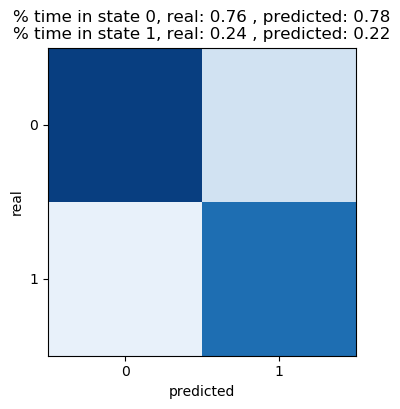

In [52]:
"""How well did it guess the state at each time?"""
state_pred = glm_hmm.most_likely_states(np.array([[o] for o in obs]), input=inputs)

conf = confusion_matrix(all_state, state_pred)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs.set_ylabel("real")
axs.set_xlabel("predicted")
axs.set_xticks([0,1])
axs.set_yticks([0,1])
axs.set_title('% time in state 0, real: ' + "%.2f" % (np.sum(all_state == 0)/len(all_state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 0)/len(state_pred)) +
              '\n% time in state 1, real: ' + "%.2f" % (np.sum(all_state == 1)/len(all_state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 1)/len(state_pred)))

Text(0.5, 1.0, "'--' for predicted, '-' for real")

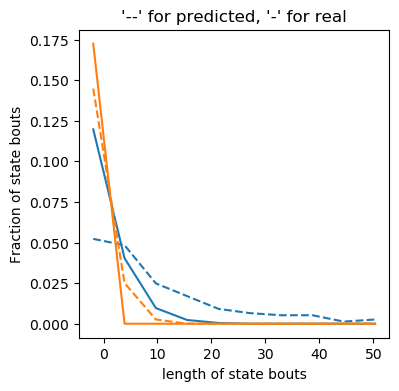

In [53]:
"""How long does each state bout last?"""

real_time = []
for i in np.arange(num_states):
    st = (all_state == i).astype(int)
    if st[0] == 1:
        st = np.hstack((np.zeros(1),st))
    if st[-1] == 1:
        st = np.hstack((st,np.zeros(1)))
    start = np.where(np.diff(st) == 1)[0]
    end = np.where(np.diff(st) == -1)[0]
    real_time.append(np.abs(start - end))

pred_time = []
for i in np.arange(num_states):
    st = (state_pred == i).astype(int)
    if st[0] == 1:
        st = np.hstack((np.zeros(1),st))
    if st[-1] == 1:
        st = np.hstack((st,np.zeros(1)))
    start = np.where(np.diff(st) == 1)[0]
    end = np.where(np.diff(st) == -1)[0]
    pred_time.append(np.abs(start - end))

longest = np.amax(np.append(np.concatenate(pred_time), np.concatenate(real_time)))
shortest = np.amin(np.append(np.concatenate(pred_time), np.concatenate(real_time)))

fig, axs = plt.subplots(1,1,figsize = (4,4))
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in np.arange(num_states):
    # real
    h, b = np.histogram(real_time[i],range = (shortest,longest), density = True)
    bc = b[:-1]-np.mean(np.diff(b))/2
    axs.plot(bc,h, '-', color = colorz[i])
    # pred
    h, b = np.histogram(pred_time[i],range = (shortest,longest), density = True)
    bc = b[:-1]-np.mean(np.diff(b))/2
    axs.plot(bc,h, '--', color = colorz[i])

axs.set_xlabel('length of state bouts')
axs.set_ylabel('Fraction of state bouts')
axs.set_title("'--' for predicted, '-' for real")

Text(0.5, 0, 'binned angles')

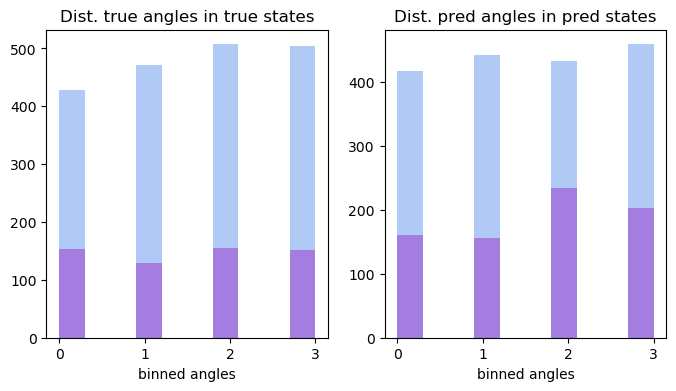

In [54]:
"""Distribution of angles in the two states"""
pred_latents, pred_angles = glm_hmm.sample(len(obs), input=inputs)

fig, axs = plt.subplots(1,2,figsize = (8,4))
axs[0].hist(obs[all_state == 0], alpha = .5, color = ['cornflowerblue'])
axs[0].hist(obs[all_state == 1], alpha = .5, color = ['darkorchid'])
axs[0].set_title('Dist. true angles in true states')
axs[0].set_xlabel('binned angles')

axs[1].hist(pred_angles[pred_latents == 0], alpha = .5, color = ['cornflowerblue'])
axs[1].hist(pred_angles[pred_latents == 1], alpha = .5, color = ['darkorchid'])
axs[1].set_title('Dist. pred angles in pred states')
axs[1].set_xlabel('binned angles')

Text(0.5, 1.0, 'pred state 1')

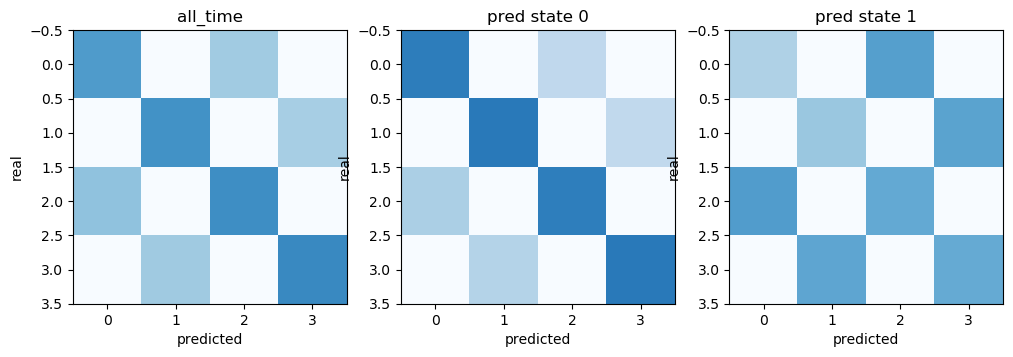

In [55]:
"""Based on the inputs, what does it think the angles should be?"""
conf = confusion_matrix(obs, pred_angles)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,3,figsize = (12,4))
axs[0].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[0].set_ylabel("real")
axs[0].set_xlabel("predicted")
axs[0].set_title("all_time")

conf = confusion_matrix(obs[pred_latents == 0], pred_angles[pred_latents == 0])
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)
axs[1].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[1].set_ylabel("real")
axs[1].set_xlabel("predicted")
axs[1].set_title("pred state 0")

conf = confusion_matrix(obs[pred_latents == 1], pred_angles[pred_latents == 1])
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)
axs[2].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[2].set_ylabel("real")
axs[2].set_xlabel("predicted")
axs[2].set_title("pred state 1")

Text(0.5, 1.0, 'weights per category\n in the two states')

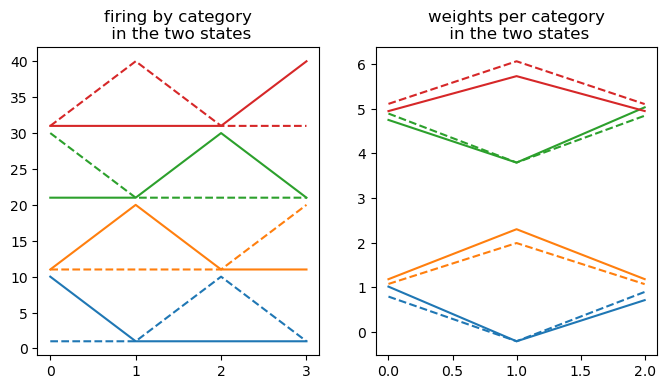

In [58]:
"""How do the tuning curves compare to the weights?"""
fig,ax = plt.subplots(1,2,figsize = (8,4))
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
linetype = ['-','--']
shift = 0
for idx in np.arange(n_inpt):
    for i in np.unique(all_state):
        i = int(i)
        y, error = firing_by_angle_bin(obs[all_state == i],inputs[all_state == i,idx], obs_cat+1)
        ax[0].fill_between(np.arange(obs_cat), y-error+shift, y+error+shift, alpha=.5, facecolor = colorz[idx], linewidth=0)
        ax[0].plot(np.arange(obs_cat),y+shift, linetype[i], color = colorz[idx])
        ax[1].plot(glm_hmm.observations.Wk[i,:,idx]+(idx*2), linetype[i], color = colorz[idx])
    shift += 10
ax[0].set_title("firing by category\n in the two states")
ax[1].set_title("weights per category\n in the two states")        